In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv(r"C:\Users\Admin\Downloads\netflix_titles.csv")


In [7]:
print(df.head())

print(df.tail())

print(df.shape)

print(df.columns)

print(df.info())

print(df.describe())

print(df.describe(include="object"))

  show_id     type  title           director  \
0      s1  TV Show     3%                NaN   
1      s2    Movie   7:19  Jorge Michel Grau   
2      s3    Movie  23:59       Gilbert Chan   
3      s4    Movie      9        Shane Acker   
4      s5    Movie     21     Robert Luketic   

                                                cast        country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...         Brazil   
1  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico   
2  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore   
3  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States   
4  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States   

          date_added  release_year rating   duration  \
0    August 14, 2020          2020  TV-MA  4 Seasons   
1  December 23, 2016          2016  TV-MA     93 min   
2  December 20, 2018          2011      R     78 min   
3  November 16, 2017          2009  PG-13     80 min   
4   

In [8]:
print(df.isnull().sum())

print((df.isnull().sum()/len(df))*100)

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64
show_id          0.000000
type             0.000000
title            0.000000
director        30.679337
cast             9.220496
country          6.510851
date_added       0.128419
release_year     0.000000
rating           0.089893
duration         0.000000
listed_in        0.000000
description      0.000000
dtype: float64


In [9]:
print(df.duplicated().sum())

df = df.drop_duplicates()

print(df.shape)

0
(7787, 12)


In [10]:
for col in df.columns:
    print(col)
    print(df[col].nunique())

show_id
7787
type
2
title
7787
director
4049
cast
6831
country
681
date_added
1565
release_year
73
rating
14
duration
216
listed_in
492
description
7769


In [11]:
print(df.dtypes)

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [14]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

print(df["date_added"].head())

0   2020-08-14
1   2016-12-23
2   2018-12-20
3   2017-11-16
4   2020-01-01
Name: date_added, dtype: datetime64[ns]


In [46]:
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()
print(df[["year_added", "month_added"]].head())

   year_added month_added
0      2020.0      August
1      2016.0    December
2      2018.0    December
3      2017.0    November
4      2020.0     January


type
Movie      5377
TV Show    2410
Name: count, dtype: int64


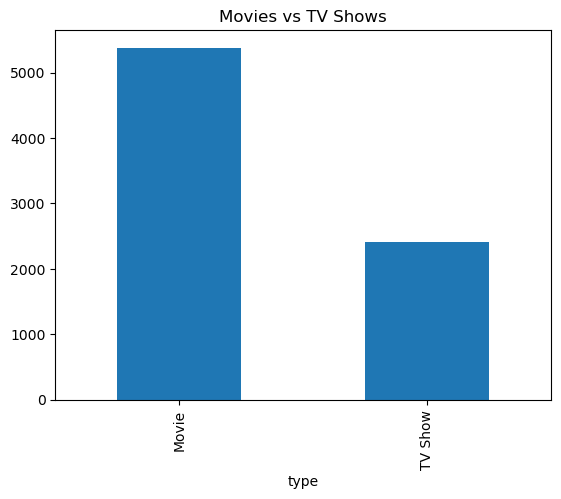

In [26]:
print(df["type"].value_counts())

df["type"].value_counts().plot(kind="bar")

plt.title("Movies vs TV Shows")

plt.show()

rating
TV-MA       2863
TV-14       1931
TV-PG        806
R            665
PG-13        386
TV-Y         280
TV-Y7        271
PG           247
TV-G         194
NR            84
G             39
TV-Y7-FV       6
UR             5
NC-17          3
Name: count, dtype: int64


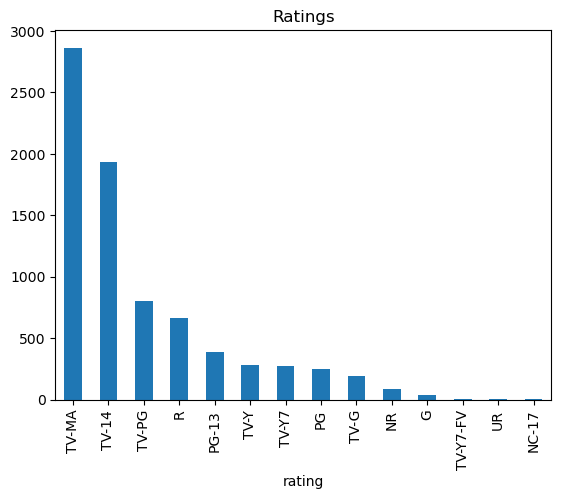

In [19]:
print(df["rating"].value_counts())

df["rating"].value_counts().plot(kind="bar")

plt.title("Ratings")

plt.xticks(rotation=90)

plt.show()

country
United States     2555
India              923
United Kingdom     397
Japan              226
South Korea        183
Canada             177
Spain              134
France             115
Egypt              101
Turkey             100
Name: count, dtype: int64


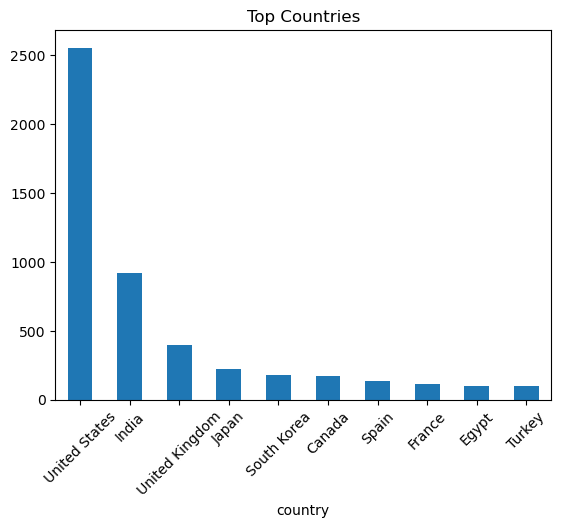

In [20]:
print(df["country"].value_counts().head(10))

df["country"].value_counts().head(10).plot(kind="bar")

plt.title("Top Countries")

plt.xticks(rotation=45)

plt.show()

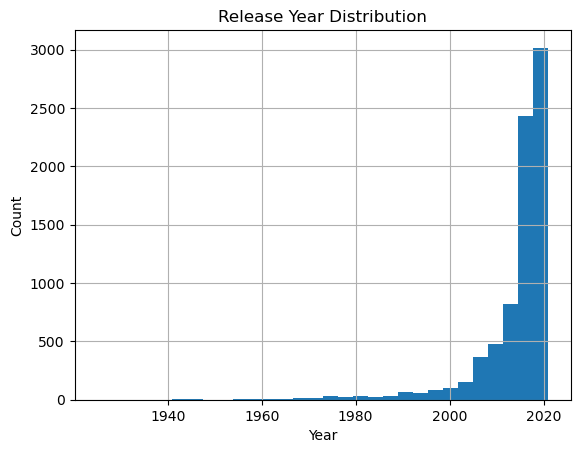

In [21]:
df["release_year"].hist(bins=30)

plt.title("Release Year Distribution")

plt.xlabel("Year")

plt.ylabel("Count")

plt.show()

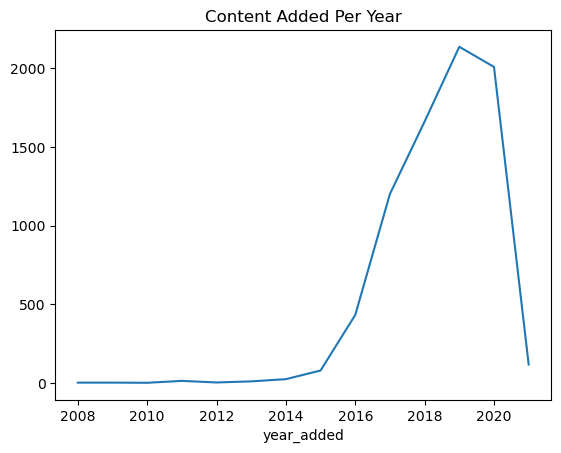

In [27]:
df["year_added"].value_counts().sort_index().plot()

plt.title("Content Added Per Year")

plt.show()

director
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Martin Scorsese           12
Jay Chapman               12
Steven Spielberg          10
David Dhawan               9
Ryan Polito                8
Name: count, dtype: int64


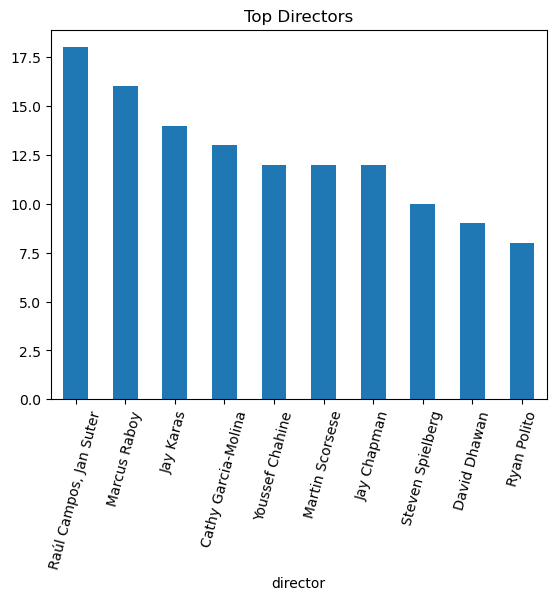

In [28]:
print(df["director"].value_counts().head(10))

df["director"].value_counts().head(10).plot(kind="bar")

plt.title("Top Directors")

plt.xticks(rotation=75)

plt.show()

cast
 Anupam Kher         38
 Takahiro Sakurai    28
 Om Puri             27
Shah Rukh Khan       27
 Boman Irani         25
 Andrea Libman       24
 Paresh Rawal        24
 Yuki Kaji           23
 Vincent Tong        22
Akshay Kumar         22
Name: count, dtype: int64


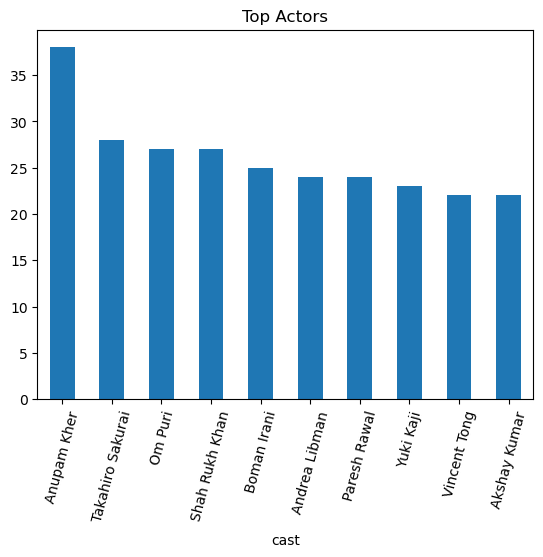

In [29]:
cast = df["cast"].dropna().str.split(",")

cast = cast.explode()

print(cast.value_counts().head(10))

cast.value_counts().head(10).plot(kind="bar")

plt.title("Top Actors")

plt.xticks(rotation=75)

plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_23968\930973906.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movie["duration"] = movie["duration"].str.replace(" min","")
C:\Users\Admin\AppData\Local\Temp\ipykernel_23968\930973906.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movie["duration"] = movie["duration"].astype(float)


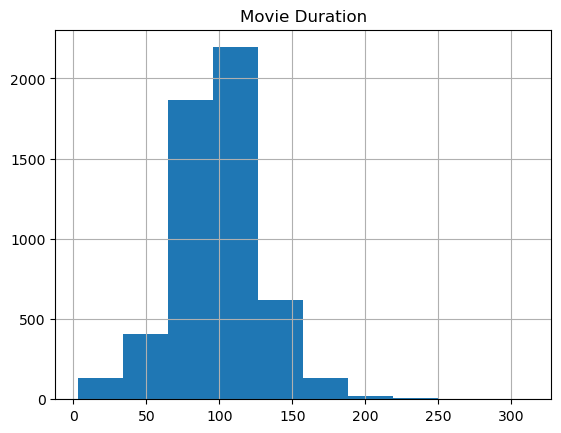

In [30]:
movie = df[df["type"]=="Movie"]

movie["duration"] = movie["duration"].str.replace(" min","")

movie["duration"] = movie["duration"].astype(float)

movie["duration"].hist()

plt.title("Movie Duration")

plt.show()

In [31]:
pd.crosstab(df["type"],df["rating"])

rating,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR
type,,,,,,,,,,,,,,
Movie,39,3,79,247,386,663,1272,111,1845,505,117,95,5,5
TV Show,0,0,5,0,0,2,659,83,1018,301,163,176,1,0


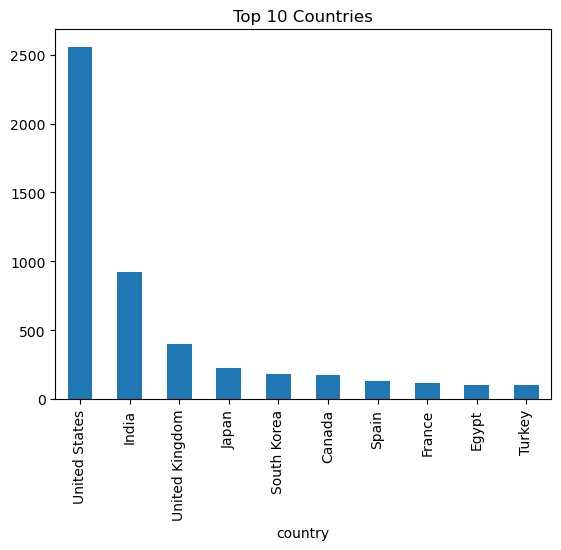

In [32]:
country = df["country"].value_counts().head(10)

country.plot(kind="bar")

plt.title("Top 10 Countries")

plt.show()

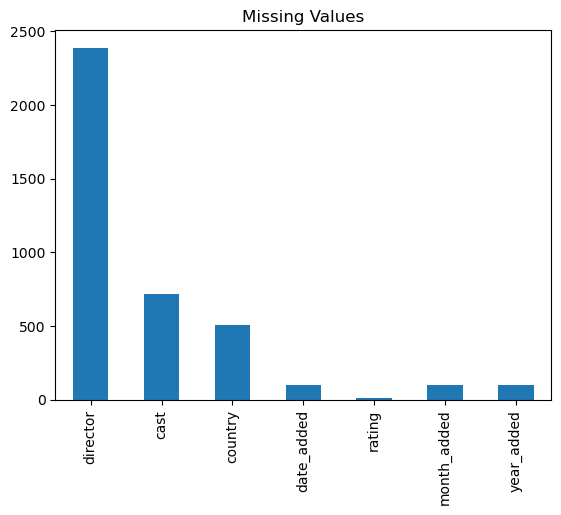

In [33]:
missing = df.isnull().sum()

missing = missing[missing>0]

missing.plot(kind="bar")

plt.title("Missing Values")

plt.show()

In [34]:
num = df.select_dtypes(include=np.number)

print(num.corr())

              release_year  year_added
release_year      1.000000    0.099601
year_added        0.099601    1.000000


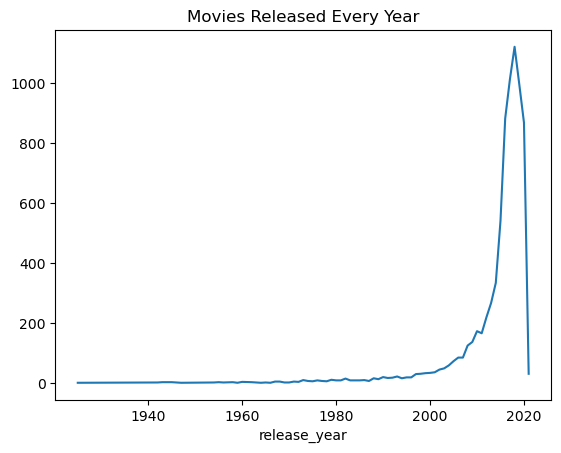

In [35]:
df.groupby("release_year")["show_id"].count().plot()

plt.title("Movies Released Every Year")

plt.show()

In [36]:
df["type"].value_counts(normalize=True)*100

type
Movie      69.050982
TV Show    30.949018
Name: proportion, dtype: float64

In [37]:
df.sort_values("release_year").head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added
4867,s4868,TV Show,Pioneers: First Women Filmmakers*,NaN,NaN,NaN,2018-12-30,1925,TV-14,1 Season,TV Shows,This collection restores films from women who ...,December,2018.0
6117,s6118,Movie,The Battle of Midway,John Ford,"Henry Fonda, Jane Darwell",United States,2017-03-31,1942,TV-14,18 min,"Classic Movies, Documentaries",Director John Ford captures combat footage of ...,March,2017.0
4960,s4961,Movie,Prelude to War,Frank Capra,NaN,United States,2017-03-31,1942,TV-14,52 min,"Classic Movies, Documentaries",Frank Capra's documentary chronicles the rise ...,March,2017.0
7679,s7680,Movie,WWII: Report from the Aleutians,John Huston,NaN,United States,2017-03-31,1943,TV-PG,45 min,Documentaries,Filmmaker John Huston narrates this Oscar-nomi...,March,2017.0
7342,s7343,Movie,Undercover: How to Operate Behind Enemy Lines,John Ford,NaN,United States,2017-03-31,1943,TV-PG,61 min,"Classic Movies, Documentaries",This World War II-era training film dramatizes...,March,2017.0


In [38]:
df.sort_values("release_year",ascending=False).head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,month_added,year_added
2327,s2328,TV Show,Gabby's Dollhouse,NaN,"Laila Lockhart Kraner, Tucker Chandler, Juliet...",NaN,2021-01-05,2021,TV-Y,1 Season,Kids' TV,"Cute cats, quirky crafts and colorful magic! J...",January,2021.0
4468,s4469,TV Show,Night Stalker: The Hunt for a Serial Killer,Tiller Russell,NaN,NaN,2021-01-13,2021,TV-MA,1 Season,"Crime TV Shows, Docuseries",Beneath the sunlit glamour of 1985 LA lurks a ...,January,2021.0
2753,s2754,TV Show,History of Swear Words,NaN,Nicolas Cage,United States,2021-01-05,2021,TV-MA,1 Season,"Docuseries, TV Comedies","Nicolas Cage hosts this proudly profane, funny...",January,2021.0
5103,s5104,Movie,Ratones Paranoicos: The Band that Rocked Argen...,"Alejandro Ruax, Ramiro Martínez","Juan Sebastián Gutiérrez, Pablo Cano, Pablo Me...",NaN,2021-01-06,2021,TV-MA,76 min,"Documentaries, International Movies, Music & M...","The irrepressible Ratones Paranoicos, Argentin...",January,2021.0
1355,s1356,Movie,Chris Rock Total Blackout: The Tamborine Exten...,Chris Rock,Chris Rock,NaN,2021-01-12,2021,TV-MA,98 min,Stand-Up Comedy,"In this extended cut of his 2018 special, Chri...",January,2021.0


In [39]:
df["release_year"].value_counts().head(10)

release_year
2018    1121
2017    1012
2019     996
2016     882
2020     868
2015     541
2014     334
2013     267
2012     219
2010     173
Name: count, dtype: int64

In [40]:
movie["duration"].mean()

np.float64(99.30797842663195)

In [41]:
df.to_csv("Netflix_Cleaned.csv",index=False)

In [44]:
##Important Insights
print("Total Rows :",df.shape[0])

print("Total Columns :",df.shape[1])

print("Movies :",df[df["type"]=="Movie"].shape[0])

print("TV Shows :",df[df["type"]=="TV Show"].shape[0])

print("Top Country")

print(df["country"].value_counts().head())

print("Top Rating")

print(df["rating"].value_counts().head())

print("Top Director")

print(df["director"].value_counts().head())


Total Rows : 7787
Total Columns : 14
Movies : 5377
TV Shows : 2410
Top Country
country
United States     2555
India              923
United Kingdom     397
Japan              226
South Korea        183
Name: count, dtype: int64
Top Rating
rating
TV-MA    2863
TV-14    1931
TV-PG     806
R         665
PG-13     386
Name: count, dtype: int64
Top Director
director
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Name: count, dtype: int64
